In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              precision_recall_fscore_support)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("loan_default_dataset.csv")
print(f"Raw shape: {df.shape}")

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows")

df["home_ownership"] = df["home_ownership"].str.upper().str.strip()

df.loc[(df["age"] < 18) | (df["age"] > 90), "age"] = np.nan
income_cap = df["annual_income"].quantile(0.995)
df["annual_income"] = df["annual_income"].clip(upper=income_cap)

print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Raw shape: (6015, 13)
Dropped 15 duplicate rows

Missing values per column:
age                          6
annual_income              180
credit_score                60
debt_to_income             120
employment_length_years    240
dtype: int64


In [3]:
TARGET = "default"
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%} | Test default rate: {y_test.mean():.2%}")

Train: (4800, 12), Test: (1200, 12)
Train default rate: 16.88% | Test default rate: 16.92%


In [4]:
numeric_cols = ["age", "annual_income", "credit_score", "loan_amount",
                 "loan_term_months", "interest_rate", "debt_to_income",
                 "employment_length_years", "num_open_accounts",
                 "num_late_payments_2yrs"]
categorical_cols = ["home_ownership", "purpose"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [5]:
print(f"Before SMOTE: {np.bincount(y_train)}")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)
print(f"After SMOTE:  {np.bincount(y_train_res)}")

Before SMOTE: [3990  810]
After SMOTE:  [3990 3990]


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE
    ),
}

results = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    y_pred = model.predict(X_test_proc)

    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

    results[name] = {"roc_auc": round(auc, 4), "precision": round(prec, 4),
                      "recall": round(rec, 4), "f1": round(f1, 4)}
    roc_data[name] = (fpr, tpr, auc)

    print(f"\n--- {name} ---")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, digits=3))


--- Logistic Regression ---
ROC-AUC: 0.8001
              precision    recall  f1-score   support

           0      0.924     0.712     0.805       997
           1      0.336     0.714     0.457       203

    accuracy                          0.713      1200
   macro avg      0.630     0.713     0.631      1200
weighted avg      0.825     0.713     0.746      1200


--- Random Forest ---
ROC-AUC: 0.7866
              precision    recall  f1-score   support

           0      0.908     0.782     0.841       997
           1      0.364     0.611     0.456       203

    accuracy                          0.753      1200
   macro avg      0.636     0.697     0.648      1200
weighted avg      0.816     0.753     0.775      1200


--- Decision Tree ---
ROC-AUC: 0.7374
              precision    recall  f1-score   support

           0      0.903     0.711     0.796       997
           1      0.306     0.626     0.411       203

    accuracy                          0.697      1200
   ma

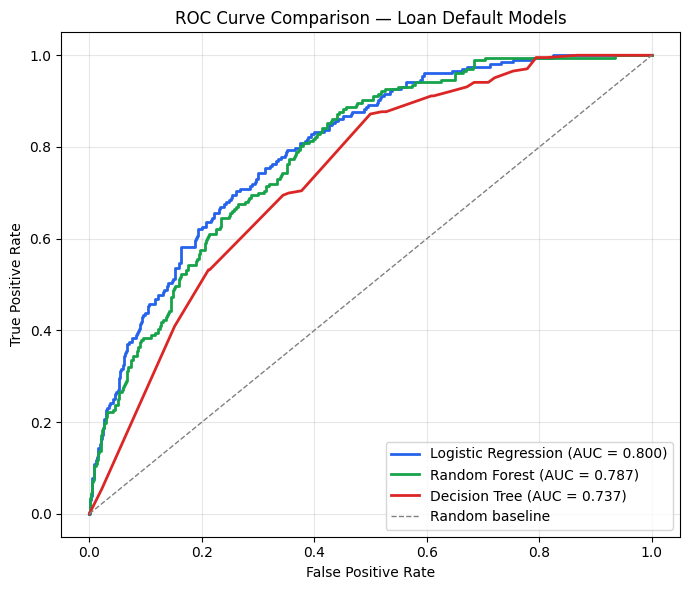

In [7]:
plt.figure(figsize=(7, 6))
colors = {"Logistic Regression": "#2563eb", "Random Forest": "#16a34a", "Decision Tree": "#dc2626"}
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=colors[name], linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Loan Default Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150)
plt.show()

In [8]:
results_df = pd.DataFrame(results).T
print(results_df)

winner = max(results, key=lambda k: results[k]["roc_auc"])
print(f"\nWinning model by ROC-AUC: {winner} ({results[winner]['roc_auc']})")

results_df.to_csv("model_comparison_table.csv")
with open("model_results.json", "w") as f:
    json.dump(results, f, indent=2)

                     roc_auc  precision  recall      f1
Logistic Regression   0.8001     0.3356  0.7143  0.4567
Random Forest         0.7866     0.3636  0.6108  0.4559
Decision Tree         0.7374     0.3060  0.6256  0.4110

Winning model by ROC-AUC: Logistic Regression (0.8001)
